In [1]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import statsmodels.api as sm
import pandas as pd
import numpy as np

from pyha_analyzer import PyhaTrainer, PyhaTrainingArguments, extractors
from pyha_analyzer.models.demo_CNN import ResnetConfig, ResnetModel
from pyha_analyzer.preprocessors import MelSpectrogramPreprocessors, MixItUp, ComposeAudioLabel
from audiomentations import Compose, AddColorNoise, AddBackgroundNoise, PolarityInversion, Gain
from pyha_analyzer.models import EfficentNet

import numpy as np
import torch
import random
import json
import librosa
import matplotlib.pyplot as plt

from egci_bioacoustic_shifts.utils import EGCI, plot_EGCI

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

2025-11-10 12:32:13.660706: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 12:32:13.753550: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762806733.811205 3717105 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762806733.826581 3717105 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762806733.921254 3717105 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Experiment Parameters
regions = ["HSN", "PER", "UHH", "SNE", "POW", "NES"]
num_samples = 2000
num_trials = 100
birdset_extactor = extractors.Birdset()
ds = birdset_extactor("HSN")

In [3]:
def load_file(path):
    y, sr  = librosa.load(path=path, sr=32_000)
    return y

def combine_files(y_1, y_2):
    if y_1.shape[-1] > y_2.shape[-1]:
        start = np.random.randint(0, y_1.shape[-1] - y_2.shape[-1])
        y_1 = y_1[start:start + y_2.shape[-1]]
    if y_2.shape[-1] > y_1.shape[-1]:
        start = np.random.randint(0, y_2.shape[-1] - y_1.shape[-1])
        y_2 = y_2[start:start + y_1.shape[-1]]

    return y_1, y_2

In [4]:
vaild_sample = ds["valid"][0]
test_sample_idx = np.random.choice(np.where(np.array(ds["test"]["labels"])[:, vaild_sample["ebird_code"]] == 1)[0])
test_sample = ds["test"][int(test_sample_idx)]

valid_y = load_file(vaild_sample["audio"]["path"])
test_y = load_file(test_sample["audio"]["path"])

test_weight = 0.5
test_y, valid_y = combine_files(test_y, valid_y)


valid_y.shape, test_y.shape

((160000,), (160000,))

0.0 0.7346345736887658 0.3518783070930517
0.02 0.7346370557389518 0.3518755223822681
0.04 0.7346441010111194 0.35186726700533455
0.06 0.7346562703952785 0.3518528858787334
0.08 0.7346741809958194 0.3518316755347043
0.1 0.7346985078089431 0.3518028864364655
0.12 0.7347299898108816 0.35176572254932065
0.14 0.7347694361139437 0.3517193398519061
0.16 0.7348177334599798 0.3516628450509425
0.18 0.7348758532851032 0.3515952914913827
0.2 0.7349448642761808 0.3515156708577935
0.22 0.735025943820795 0.35142290338327786
0.24 0.7351203940696766 0.35131582619190505
0.26 0.7352296600360189 0.3511931712486719
0.28 0.7353553518224772 0.3510535418491741
0.3 0.7354992681590241 0.35089538492179645
0.32 0.7356634274074396 0.35071695338689646
0.34 0.7358500994439429 0.35051626151461673
0.36 0.7360618455625306 0.3502910310414884
0.38 0.7363015610500643 0.35003862660772495
0.4 0.7365725291781215 0.34975597184453877
0.42 0.7368784770645908 0.34943945286915523
0.44 0.7372236430461836 0.3490847952348253
0.46 0.

<Axes: xlabel='Entropy [Hf]', ylabel='Complexity [Cf]'>

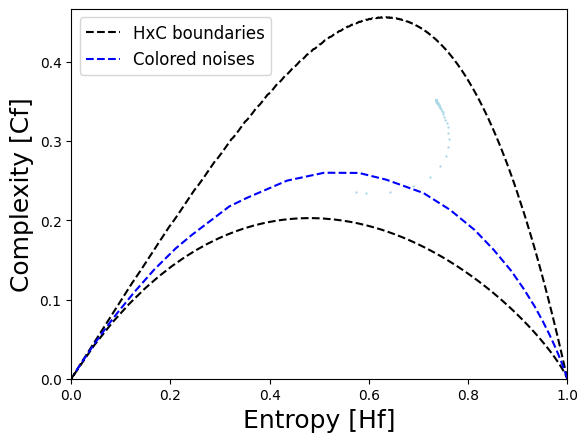

In [5]:
H = []
C = []
for i in range(51):
    weight = i / 50
    h,c,lag = EGCI((1 - weight) * valid_y + weight * test_y, 256)
    H.append(h)
    C.append(c)
    print(weight, h, c)

plot_EGCI(H, C, lag, axes=plt.subplot(111))


In [11]:
sample = 2000
indx_sampled = np.random.randint(0, len(ds["valid"]), sample)
indx_sampled

from tqdm import tqdm 


def get_data_per_region(region):
    ds = birdset_extactor(region)
    data = []

    for i in tqdm(range(len(ds["valid"]))):

        vaild_sample = ds["valid"][int(i)]
        test_sample_idx = np.random.choice(np.where(np.array(ds["test"]["labels"])[:, vaild_sample["ebird_code"]] == 1)[0])
        test_sample = ds["test"][int(test_sample_idx)]

        valid_y = load_file(vaild_sample["audio"]["path"])
        test_y = load_file(test_sample["audio"]["path"])

        test_y, valid_y = combine_files(test_y, valid_y)
        data.append((valid_y.tolist(), test_y.tolist(), vaild_sample, test_sample))
        break

    return data

data = get_data_per_region("HSN")

  0%|          | 0/1092 [00:06<?, ?it/s]


In [12]:
data

[([-0.002086400054395199,
   0.007540492340922356,
   0.009966300800442696,
   0.012868980877101421,
   0.01699289306998253,
   0.014188224449753761,
   0.008323244750499725,
   0.004412787035107613,
   -0.000869089737534523,
   -0.0060732485726475716,
   -0.006976069882512093,
   -0.004476887173950672,
   -0.0005676904693245888,
   0.0008823788957670331,
   -0.0027321467641741037,
   -0.005053109489381313,
   -0.0017026427667587996,
   0.002125031314790249,
   0.00437278114259243,
   0.006705365609377623,
   0.006152137648314238,
   0.001996879233047366,
   -0.002744407393038273,
   -0.009326621890068054,
   -0.01750575378537178,
   -0.021472403779625893,
   -0.020259052515029907,
   -0.018474992364645004,
   -0.017199013382196426,
   -0.014872848987579346,
   -0.012313400395214558,
   -0.011489413678646088,
   -0.011821256950497627,
   -0.009694063104689121,
   -0.004088098648935556,
   0.00027190009132027626,
   0.00022967904806137085,
   -0.002412887290120125,
   -0.008084917441010

In [7]:
# from collections import defaultdict

# def compute_egci(data, ax=plt.subplot(111), region="HSN", frist=True):
#     H = defaultdict(list)
#     C = defaultdict(list)
#     H_avgs = []
#     C_avgs = []
#     total = 10
#     for i in tqdm(range(total + 1),  position=0, leave=True):
#         for (valid_y, test_y) in tqdm(data,  position=1, leave=False):
#             weight = i / total
#             h,c,lag = EGCI((1 - weight) * np.array(valid_y) + weight * np.array(test_y), 256)
#             H[i].append(float(h))
#             C[i].append(float(c))

#         H_avgs.append(float(np.mean(H[i])))
#         C_avgs.append(float(np.mean(C[i])))
#         print(H_avgs[-1], C_avgs[-1])

#     ax = plot_EGCI(H_avgs, C_avgs, lag, axes=ax, label=region, plot_boundries=frist)
#     return ax, H, C
# compute_egci(data)

In [8]:
# ax = plt.subplot(111)

# region_data = {}
# for region in regions:
#     data = get_data_per_region(region)
#     ax, H, C = compute_egci(data, ax=ax, region=region, frist=region == regions[0])
#     region_data[region] = {
#         "H":H,
#         "C": C,
#         "data": data
#     }


In [9]:
region_data["HSN"]["H"]

NameError: name 'region_data' is not defined

In [ ]:
# import json

# with open("new_e3.json", mode="w") as f:
#     #json.dump(region_data, f)
#     json.dump(list(region_data["HSN"]["data"][0][0]), f)
# # region_data

TypeError: Object of type float32 is not JSON serializable

In [10]:
preprocessor = MelSpectrogramPreprocessors(
    duration=5, 
    augment=None,
)

ds["train"].set_transform(preprocessor)
ds["valid"].set_transform(preprocessor)
ds["test"].set_transform(preprocessor)

model = EfficentNet(num_classes=len(ds["train"].features["ebird_code"].names))


In [21]:
weight = 0.5

In [22]:
(valid_y, test_y, vaild_sample, test_sample) = data[0]
weighted_y = (1 - weight) * np.array(valid_y) + weight * np.array(test_y)

In [ ]:
import torchvision.transforms as transforms

def fake_preprocessor(weighted_y, vaild_sample):
    n_fft=2048
    hop_length=256
    power=2.0
    n_mels=256

    pillow_transforms = transforms.ToPILImage()
        
    mels = np.array(
        pillow_transforms(
            librosa.feature.melspectrogram(
                y=weighted_y, sr=32_000,
                n_fft=n_fft, 
                hop_length=hop_length, 
                power=power, 
                n_mels=n_mels, 
            )
        ),
        np.float32)[np.newaxis, ::] / 255

    # model()
    batch = {
        "audio_in": torch.Tensor([mels]).cuda(),
        "audio": torch.Tensor([mels]).cpu(),
        "labels": torch.Tensor([vaild_sample["labels"]]).cuda()
    }
    return batch


def get_model_performance(data):
    model_outs = []
    for (valid_y, test_y, vaild_sample, test_sample) in data:
        model_outs.append(model(**fake_preprocessor(weighted_y, vaild_sample)))
    



{'loss': tensor(0.6668, device='cuda:0',
        grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'logits': tensor([[-0.0319, -0.2691,  0.1149, -0.1601, -0.0488,  0.0658, -0.0156, -0.2557,
           0.0850,  0.0541, -0.2286,  0.0174, -0.1063,  0.0909, -0.0944, -0.0016,
          -0.0930,  0.1679, -0.0323, -0.0959,  0.3862]], device='cuda:0',
        grad_fn=<AddmmBackward0>)}

In [2]:
import torch

torch.ones(100).cuda().detach().cpu().numpy().tolist()

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [1]:
import json
with open("e3_results_new_method_temp.json", "r") as file:
    data = json.load(file)

In [10]:
len(data["HSN"]["H"]["0"])

1092

In [11]:
data["HSN"]["H"].keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10'])

In [21]:
import numpy as np

for i in range(11):
    print(i, np.median([x["loss"] for x in data["HSN"]["outs"][str(i)]]))

0 0.16937866061925888
1 0.16978895664215088
2 0.17104212194681168
3 0.17009379714727402
4 0.17012768983840942
5 0.169981449842453
6 0.17023558914661407
7 0.16989698261022568
8 0.17015662044286728
9 0.16979091614484787
10 0.16974414885044098


In [22]:
for i in range(11):
    print(i, np.median([x["loss"] for x in data["PER"]["outs"][str(i)]]))

0 0.042992569506168365
1 0.04300878569483757
2 0.04292992874979973
3 0.04291784390807152
4 0.04296814650297165
5 0.042941685765981674
6 0.042969655245542526
7 0.04307316988706589
8 0.04310786724090576
9 0.04300130531191826
10 0.043392036110162735


In [23]:
for i in range(11):
    print(i, np.median([x["loss"] for x in data["UHH"]["outs"][str(i)]]))

0 0.10230112448334694
1 0.10255128145217896
2 0.10201523080468178
3 0.10283079743385315
4 0.10246970504522324
5 0.10265073552727699
6 0.10218904539942741
7 0.10220236331224442
8 0.10257506743073463
9 0.10208568349480629
10 0.10189445316791534
